In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt



(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [ ]:
x_train=x_train.astype('float32')/255.0
x_test=x_test.astype('float32')/255.0
x_train=x_train.reshape(-1,784)
x_test=x_test.reshape(-1,784)

In [ ]:
def build_mlp(hidden_units, learning_rate):
  model = models.Sequential([
      layers.Input(shape=(784,)),
      layers.Dense(hidden_units, activation='relu'),
      layers.Dense(64, activation='relu'),
      layers.Dense(10, activation='softmax')
  ])
  optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
  model.compile(optimizer=optimizer,
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
  return model

In [ ]:
configs=[
    {'hidden_unit':64, 'learning_rate':0.001, 'batch_size':32},
    {'hidden_unit':128, 'learning_rate':0.001, 'batch_size':64},
    {'hidden_unit':128, 'learning_rate':0.001, 'batch_size':64},
    {'hidden_unit':256, 'learning_rate':0.001, 'batch_size':128},
]

history_results = {}
test_results  = {}


In [ ]:
for cfg in configs:
  print(f"\nTraining with {cfg}")
  model = build_mlp(cfg['hidden_unit'], cfg['learning_rate'])
  history = model.fit(x_train, y_train, validation_split = 0.2 ,epochs = 10, batch_size = cfg['batch_size'], verbose= 1)
  history_results[str(cfg)] = history.history
  test_loss, test_acc = model.evaluate(x_test, y_test, verbose = 1)
  test_results[str(cfg)] = test_acc
  print(f"Test accuracy: {test_acc:.4f}")


Training with {'hidden_unit': 64, 'learning_rate': 0.001, 'batch_size': 32}
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8426 - loss: 0.5425 - val_accuracy: 0.9493 - val_loss: 0.1746
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9556 - loss: 0.1553 - val_accuracy: 0.9632 - val_loss: 0.1243
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9709 - loss: 0.1029 - val_accuracy: 0.9676 - val_loss: 0.1069
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9775 - loss: 0.0734 - val_accuracy: 0.9710 - val_loss: 0.0987
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9832 - loss: 0.0561 - val_accuracy: 0.9679 - val_loss: 0.1154
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9834 - loss: 0.0525 - val_accuracy: 0.9690 - val_loss: 0.1020
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9883 - loss: 0.0387 - val_accuracy: 0.9716 - val_loss: 0.1023
Epoch 8/10
15

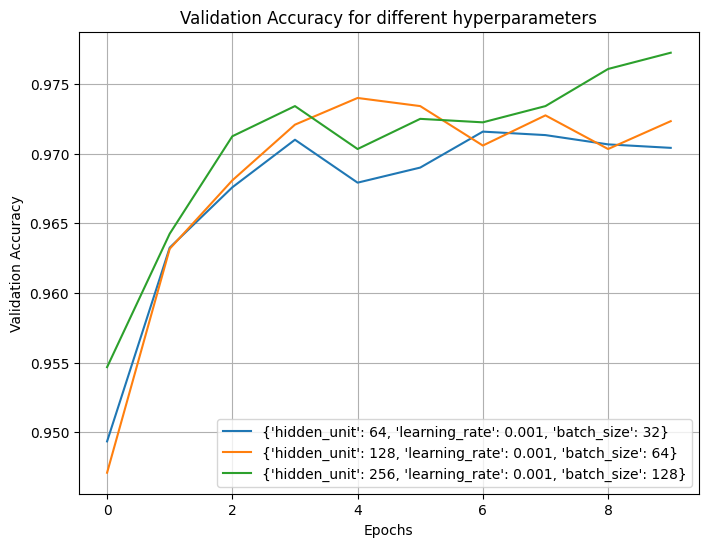

In [ ]:
plt.figure(figsize=(8,6))
for config,hist in history_results.items():
  plt.plot(hist['val_accuracy'],label=config)
plt.title('Validation Accuracy for different hyperparameters')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

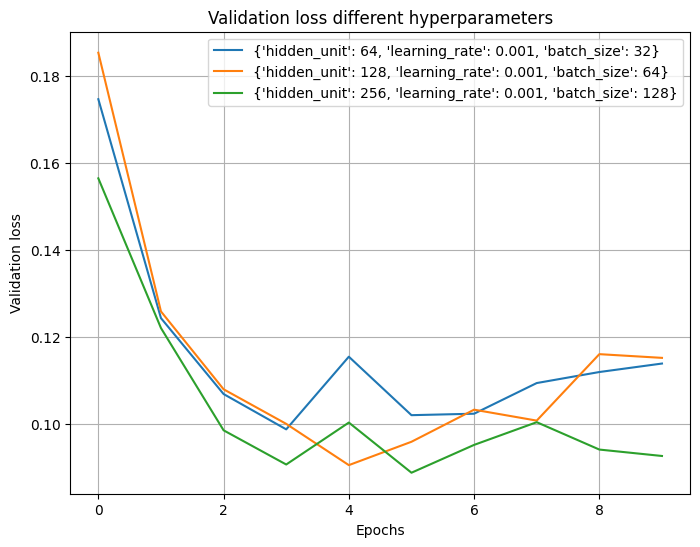

In [ ]:
plt.figure(figsize=(8,6))
for config,hist in history_results.items():
  plt.plot(hist['val_loss'],label=config)
plt.title('Validation loss different hyperparameters')
plt.xlabel('Epochs')
plt.ylabel('Validation loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("\nFinal Test Accuracy Comarission:")
for config,acc in test_results.items():
  print(f"{config}:{acc:.4f}")


Final Test Accuracy Comarission:
{'hidden_unit': 64, 'learning_rate': 0.001, 'batch_size': 32}:0.9738
{'hidden_unit': 128, 'learning_rate': 0.001, 'batch_size': 64}:0.9742
{'hidden_unit': 256, 'learning_rate': 0.001, 'batch_size': 128}:0.9774
